In [1]:
%config Completer.use_jedi = False

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import warnings
import math
import numpy as np

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'

org_data = pd.read_csv( '../../training_data/ewma_6h_scaling.csv')
org_data = org_data[['REG_DTIME', 'h_dong', 'count', 'pops', 'windspd' , 'humid' , 'temp', 'precip_form', 'precip', 'isHoliday']]
dongs = org_data['h_dong'].unique()

In [3]:
nei_dong = {
    '동산면' : ['동내면' , '신동면', '남산면'],
    '후평1동' :['동  면' , '신사우동', '근화동', '소양동', '교  동', ],
    '사북면' : ['서  면' , '신북읍'],
    '신북읍' : ['북산면' , '사북면' , '서  면', '신사우동' , '동  면'], 
    '석사동' : ['동내면', '동  면', '퇴계동'],
    '남산면' : ['동산면', '신동면', '서  면' , '남  면'],
    '교  동' : ['후평1동' , '소양동' , '조운동' , ],
    '신동면' : ['동내면' , '퇴계동', '강남동', '서  면', '남산면', '동산면'],
    '효자1동': ['조운동', '약사명동','근화동','강남동', '퇴계동', ],
    '북산면' : ['신북읍', '동  면'],
    '서  면' : ['신사우동', '신북읍', '사북면', '남산면', '신동면', '강남동', '근화동'],
    '조운동' : ['교  동', '소양동' , '약사명동', '효자1동'],
    '동내면' : ['동  면', '석사동', '퇴계동', '신동면' , '동산면'],
    '강남동' : ['퇴계동', '효자1동', '근화동','서  면' , '신동면'],
    '퇴계동' : ['석사동', '강남동', '신동면'],
    '근화동' : ['신사우동' , '서  면' , '강남동', '약사명동', '소양동'] , 
    '동  면' : ['북산면' , '신북읍', '신사우동', '후평1동' , '석사동' , '동내면'],
    '신사우동':['동  면' , '신북읍','서  면' , '근화동' , '후평1동'],
    '약사명동':['소양동' , '근화동','효자1동', '조운동'],
    '남  면' : ['남산면']
}
for key in nei_dong.keys():
    print(key , nei_dong[key])

동산면 ['동내면', '신동면', '남산면']
후평1동 ['동  면', '신사우동', '근화동', '소양동', '교  동']
사북면 ['서  면', '신북읍']
신북읍 ['북산면', '사북면', '서  면', '신사우동', '동  면']
석사동 ['동내면', '동  면', '퇴계동']
남산면 ['동산면', '신동면', '서  면', '남  면']
교  동 ['후평1동', '소양동', '조운동']
신동면 ['동내면', '퇴계동', '강남동', '서  면', '남산면', '동산면']
효자1동 ['조운동', '약사명동', '근화동', '강남동', '퇴계동']
북산면 ['신북읍', '동  면']
서  면 ['신사우동', '신북읍', '사북면', '남산면', '신동면', '강남동', '근화동']
조운동 ['교  동', '소양동', '약사명동', '효자1동']
동내면 ['동  면', '석사동', '퇴계동', '신동면', '동산면']
강남동 ['퇴계동', '효자1동', '근화동', '서  면', '신동면']
퇴계동 ['석사동', '강남동', '신동면']
근화동 ['신사우동', '서  면', '강남동', '약사명동', '소양동']
동  면 ['북산면', '신북읍', '신사우동', '후평1동', '석사동', '동내면']
신사우동 ['동  면', '신북읍', '서  면', '근화동', '후평1동']
약사명동 ['소양동', '근화동', '효자1동', '조운동']
남  면 ['남산면']


In [4]:
nei_edge_df = pd.DataFrame(columns = ['source' , 'target' , 'weight'])

idx = 0
for key in nei_dong.keys():
    for nei in nei_dong[key]:
        nei_edge_df.loc[idx] = [key, nei , 1 ,]
        idx += 1
        
nei_node_df = pd.DataFrame(
    {
    'adm' : dongs,
    'color' : np.full(len(dongs) , 'yellow' )
})

In [5]:
adm_G = nx.from_pandas_edgelist(nei_edge_df , source='source' , target='target' , edge_attr = ['weight'])
nodes_attr = nei_node_df.set_index('adm').to_dict(orient='index')
nx.set_node_attributes(adm_G, nodes_attr)

[]

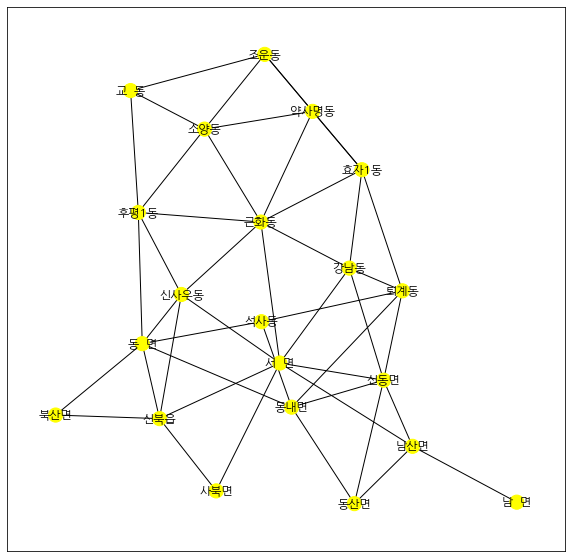

In [6]:
plt.figure(figsize=(10,10)) 
nx.draw_networkx(adm_G, 
    pos = nx.kamada_kawai_layout(adm_G, weight = 'weights'), 
    node_size = 200, 
    node_color = [adm_G.nodes[n]['color'] for n in adm_G.nodes],
    width = [adm_G.edges[e]['weight'] for e in adm_G.edges],
    
    font_family='NanumGothic',
    with_labels = True)
plt.plot()

In [7]:
def k_nbrs_in(G, start, k):
    nbrs = set([start])
    for l in range(k):
        nbrs = set((nbr for n in nbrs for nbr in G[n]))
    return nbrs  | set([start])

def k_nbrs(G, start, k):
    nbrs = set([start])
    for l in range(k):
        nbrs = set((nbr for n in nbrs for nbr in G[n]))
    return nbrs 


In [8]:
# uncolored_graph 
p1 , p2 ,p3 = 0 ,1 , 0
dts = org_data['REG_DTIME'].unique()#.astype(str)
dongs = org_data['h_dong'].unique()
graph_count = []
for idx in org_data.index:
    dt = org_data['REG_DTIME'].loc[idx]
    dong = org_data['h_dong'].loc[idx]
    #print(dt,dong)
    time_data = org_data[org_data['REG_DTIME'] == dt]
    nei_dong_data1 = time_data[time_data['h_dong'].isin(k_nbrs(adm_G, dong, 1))]
    nei_dong_data2 = time_data[time_data['h_dong'].isin(k_nbrs(adm_G, dong, 2))]

    
    #org_data.loc[idx,'count'] = sum(nei_dong_data['count'])
    val = (p1 * org_data['count'].loc[idx]) + (p2 * sum(nei_dong_data1['count'])) + (p3*sum(nei_dong_data2['count']))
    print(val)
    graph_count.append(val)

org_data['count'] = graph_count
org_data.to_csv('weighted_graph_data2.csv')

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
0.1538461538461538
0.1538461538461538
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
0.0
0.1538461538461538
0.0
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
0.0
0.0
0.3076923076923077
0.0
0.3076923076923077
0.3076923076923077
0.0
0.0
0.0
0.0
0.3076923076923077
0.0
0.0
0.3076923076923077
0.0
0.0
0.0
0.0
0.0
0.3076923076923077
0.0
0.0
0.0
0.9230769230769232
0.0
0.9230769230769232
0.9230769230769232
0.0
0.0
0.0
0.0
0.9230769230769232
0.0
0.0
0.9230769230769232
0.0
0.0
0.0
0.0
0.0
0.9230769230769232
0.0
0.0
0.0
0.3076923076923077
0.0
0.3076923076923077
0.3076923076

0.4615384615384615
0.0
0.6153846153846154
0.4615384615384615
0.0
0.0
0.4615384615384615
0.0
0.4615384615384615
0.4615384615384615
0.0
0.0
0.0
0.0
0.4615384615384615
0.0
0.9230769230769232
0.4615384615384615
0.0
0.9230769230769232
0.9230769230769232
0.9230769230769232
0.0
0.4615384615384615
0.9230769230769232
0.0
0.0
0.3076923076923077
0.0
0.3076923076923077
0.3076923076923077
0.0
0.0
0.0
0.0
0.3076923076923077
0.0
2.923076923076924
0.3076923076923077
0.0
2.923076923076924
2.923076923076924
2.923076923076924
0.0
0.3076923076923077
2.923076923076924
0.0
0.0
0.1538461538461538
0.0
0.1538461538461538
0.1538461538461538
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
0.9230769230769232
0.1538461538461538
0.0
0.9230769230769232
0.9230769230769232
0.9230769230769232
0.0
0.1538461538461538
0.9230769230769232
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.6153846153846154
0.0
0.0
0.6153846153846154
0.6153846153846154
0.6153846153846154
0.0
0.0
0.6153846153846154
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.

1.8461538461538465
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.6153846153846154
0.0
0.0
0.0
0.0
0.0
0.0
0.6153846153846154
0.0
0.0
0.6153846153846154
0.6153846153846154
0.6153846153846154
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.4615384615384615
0.0
0.0
0.0
0.0
0.0
0.0
0.4615384615384615
0.0
0.0
0.4615384615384615
0.4615384615384615
0.4615384615384615
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.3076923076923077
0.0
0.0
0.0
0.0
0.0
0.0
0.3076923076923077
0.0
0.0
0.3076923076923077
0.3076923076923077
0.3076923076923077
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
0.0
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
0.0
0.1538461538461538
0.1538461538461538
0.1538461538461538
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0

0.0
0.0
0.0
0.1538461538461538
0.1538461538461538
0.0
0.0
0.0
0.0
0.3076923076923077
0.0
0.0
0.0
0.0
0.0
0.0
0.3076923076923077
0.3076923076923077
0.0
0.1538461538461538
0.0
0.0
0.1538461538461538
0.0
0.4615384615384615
0.3076923076923077
0.0
0.0
0.0
0.0
0.6153846153846154
0.0
0.0
0.0
0.0
0.0
0.0
0.6153846153846154
0.6153846153846154
0.0
0.3076923076923077
0.0
0.0
0.3076923076923077
0.0
0.9230769230769231
0.6153846153846154
0.0
0.0
0.0
0.0
1.8461538461538465
0.0
0.0
0.0
0.0
0.0
0.0
1.8461538461538465
1.8461538461538465
0.0
0.6153846153846154
0.0
0.0
0.6153846153846154
0.0
2.4615384615384617
1.8461538461538465
0.0
0.0
0.0
0.0
0.6153846153846154
0.0
0.0
0.0
0.0
0.0
0.0
0.6153846153846154
0.6153846153846154
0.0
1.8461538461538465
0.0
0.0
1.8461538461538465
0.0
2.4615384615384617
0.6153846153846154
0.0
0.0
0.0
0.0
0.4615384615384615
0.1538461538461538
0.0
0.0
0.0
0.0
0.0
0.4615384615384615
0.4615384615384615
0.0
0.6153846153846154
0.0
0.0
0.6153846153846154
0.0
1.2307692307692306
0.4615384

0.7692307692307692
0.1538461538461538
0.0
0.0
0.6153846153846153
0.0
0.4615384615384615
0.4615384615384615
0.0
0.1538461538461538
0.0
0.0
0.4615384615384615
0.0
0.1538461538461538
0.6153846153846153
0.0
0.0
0.1538461538461538
0.1538461538461538
0.1538461538461538
0.4615384615384615
0.1538461538461538
0.0
0.0
0.4615384615384615
0.0
0.6153846153846153
0.3076923076923077
0.0
0.0
0.0
0.0
0.3076923076923077
0.3076923076923076
0.0
0.7692307692307692
0.0
0.0
0.4615384615384615
0.1538461538461538
0.6153846153846153
0.3076923076923077
0.0
0.0
0.0
0.4615384615384615
0.0
0.7692307692307692
0.1538461538461538
0.0
0.0
0.0
0.0
0.1538461538461538
0.6153846153846154
0.0
1.3846153846153846
0.0
0.0
1.2307692307692308
0.3076923076923077
1.5384615384615385
0.1538461538461538
0.0
0.0
0.0
0.6153846153846154
0.0
1.5384615384615388
0.0
0.0
0.0
0.0
0.0
0.0
1.5384615384615388
0.0
1.2307692307692308
0.0
0.0
1.2307692307692308
0.6153846153846154
1.8461538461538463
0.0
0.0
0.0
0.0
1.8461538461538465
0.0
2.15384615

...

0.0
0.1538461538461538
0.1538461538461538
0.0
0.0
0.0
0.1538461538461538
0.0
0.1538461538461538
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.3076923076923077
0.3076923076923077
0.0
0.3076923076923077
0.3076923076923077
0.0
0.0
0.0
0.3076923076923077
0.0
0.3076923076923077
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.6153846153846154
0.1538461538461538
0.0
0.6153846153846154
0.6153846153846154
0.0
0.0
0.0
0.6153846153846154
0.0
0.6153846153846154
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
1.5384615384615383
0.1538461538461538
0.0
1.5384615384615383
1.5384615384615383
0.1538461538461538
0.1538461538461538
0.0
1.5384615384615383
0.0
1.5384615384615383
0.0
0.0
0.1538461538461538
0.1538461538461538
0.0
0.0
0.0
0.1538461538461538
0.3076923076923077
0.0
2.307692307692308
0.0
0.0
2.307692307692308
2.4615384615384617
0.3076923076923077
0.4615384615384615
0.0
2.307692307692308
0.1538461538461538
2.4615384615384617
0.0
0.0
0.3076923076923077
0.4615384615384615
0.1538461538461538
0.0
0.0
0.3

2.307692307692308
0.4615384615384615
2.615384615384616
0.0
1.0769230769230769
1.8461538461538465
2.153846153846154
0.4615384615384615
0.1538461538461538
0.3076923076923077
2.307692307692308
1.8461538461538465
0.6153846153846154
1.8461538461538465
1.0769230769230769
0.0
0.4615384615384615
0.6153846153846153
0.0
0.0
2.0000000000000004
0.7692307692307692
0.4615384615384615
2.4615384615384617
0.0
0.7692307692307692
0.6153846153846154
0.7692307692307692
0.1538461538461538
0.0
0.1538461538461538
1.0769230769230769
0.6153846153846154
1.8461538461538465
0.6153846153846154
1.5384615384615385
0.0
1.076923076923077
1.076923076923077
0.0
0.0
0.6153846153846154
0.4615384615384615
1.076923076923077
1.0769230769230769
0.0
1.2307692307692308
0.4615384615384615
0.4615384615384615
0.1538461538461538
0.0
0.1538461538461538
1.5384615384615385
0.4615384615384615
0.6153846153846154
0.4615384615384615
0.6153846153846154
0.0
0.3076923076923077
0.3076923076923077
0.0
0.0
0.4615384615384615
0.3076923076923077
0

0.0
0.1538461538461538
0.0
0.0
0.0
0.0
0.4615384615384615
0.0
0.4615384615384615
0.0
0.1538461538461538
0.0
0.0
0.6153846153846153
0.1538461538461538
0.0
0.1538461538461538
0.1538461538461538
0.3076923076923076
0.4615384615384615
0.0
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
0.1538461538461538
0.1538461538461538
0.3076923076923076
0.0
0.0
0.0
0.1538461538461538
0.1538461538461538
0.1538461538461538
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
0.0
0.0
0.0
0.0
0.4615384615384615
0.0
0.1538461538461538
0.4615384615384615
0.6153846153846153
0.0
0.0
0.0
0.4615384615384615
0.1538461538461538
0.4615384615384615
0.0
0.0
0.0
0.0
0.1538461538461538
0.0
0.0
0.0
0.0
0.0
1.3846153846153846
0.0
0.0
1.3846153846153846
1.3846153846153846
0.0
0.0
0.0
1.3846153846153846
0.0
1.3846153846153846
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.2307692307692308
0.0
0.0
1.2307692307692308
1.2307692307692308
0.0
0.0
0.0
1.3846153846153846
0.0
1.2307692307692308
0.1538461538461538
0.0
0.1538461538461538
0.0
0.0
0.0
0.0
0.0
0.

0.6153846153846154
0.6153846153846154
0.9230769230769232
0.9230769230769232
0.0
1.5384615384615388
0.0
0.6153846153846154
0.9230769230769232
0.0
1.8461538461538465
0.9230769230769232
0.0
0.0
0.0
0.0
0.3076923076923077
0.0
2.0
0.0
0.0
2.0
2.0
0.3076923076923077
0.3076923076923077
0.1538461538461538
2.3076923076923075
0.0
2.1538461538461537
0.4615384615384615
0.1538461538461538
0.6153846153846154
0.3076923076923077
0.1538461538461538
0.0
0.1538461538461538
0.0
0.1538461538461538
0.0
0.7692307692307692
0.0
0.0
0.7692307692307692
0.6153846153846154
0.1538461538461538
0.1538461538461538
0.4615384615384615
0.7692307692307692
0.0
1.0769230769230769
0.7692307692307692
0.4615384615384615
0.4615384615384614
0.1538461538461538
0.4615384615384615
0.0
0.3076923076923077
0.0
0.1538461538461538
0.0
0.7692307692307692
0.0
0.0
0.7692307692307692
0.4615384615384615
0.1538461538461538
0.1538461538461538
0.9230769230769232
0.6153846153846153
0.0
1.3846153846153848
1.3846153846153848
0.9230769230769232
0.6

0.0
0.0
0.3076923076923077
0.3076923076923076
0.0
0.0
0.0
1.076923076923077
0.0
0.0
1.2307692307692308
0.9230769230769232
0.0
0.1538461538461538
0.0
1.2307692307692308
0.0
0.9230769230769232
0.4615384615384615
0.0
0.4615384615384615
0.0
0.0
0.1538461538461538
0.1538461538461538
0.0
0.0
0.0
0.3076923076923077
0.0
0.0
0.4615384615384615
0.3076923076923077
0.0
0.1538461538461538
0.0
0.4615384615384615
0.0
0.3076923076923077
0.1538461538461538
0.0
0.1538461538461538
0.0
0.0
0.1538461538461538
0.0
0.1538461538461538
0.0
0.1538461538461538
0.1538461538461538
0.0
0.0
0.1538461538461538
0.1538461538461538
0.0
0.1538461538461538
0.0
0.1538461538461538
0.0
0.1538461538461538
0.0
0.1538461538461538
0.1538461538461538
0.0
0.0
0.0
0.0
0.3076923076923077
0.0
0.3076923076923077
0.1538461538461538
0.0
0.0
0.1538461538461538
0.1538461538461538
0.0
0.3076923076923077
0.0
0.1538461538461538
0.0
0.1538461538461538
0.0
0.3076923076923077
0.3076923076923077
0.0
0.0
0.0
0.0
0.6153846153846154
0.0
0.615384615

In [9]:
#data = pd.read_csv('weighted_graph_data1.csv')
#plt.figure(figsize=(20,6))
#x = range(len(data))
#plt.scatter(x , data['count'], s=1)
#plt.title('weighted_graph_count')